In [18]:
# Imports
import os
import cv2
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2" 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from collections import Counter

In [2]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [3]:
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes


In [4]:
# Filter out classes with only 1 sample
counts = Counter(y)
valid_classes = [cls for cls, c in counts.items() if c > 1]

X_filtered = []
y_filtered = []
for xi, yi in zip(X, y):
    if yi in valid_classes:
        X_filtered.append(xi)
        y_filtered.append(yi)

X = np.array(X_filtered)
y = np.array(y_filtered)

# 🔹 Remap labels to start from 0
unique_classes = sorted(set(y))
class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
y_mapped = np.array([class_mapping[yi] for yi in y])

# One-hot encode with correct num_classes
y_cat = to_categorical(y_mapped, num_classes=len(unique_classes))

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)
print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Train: (3438, 128, 128, 3), Test: (860, 128, 128, 3)


In [6]:
# Build ResNet Model
num_classes = len(np.unique(y))  

base_model = ResNet50(include_top=False, 
                      input_shape=(IMG_SIZE, IMG_SIZE, 3), 
                      weights=None)  

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │        69,666 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,657,378 (90.25 MB)

 Trainable params: 23,604,258 (90.04 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [7]:
print("Unique classes in y:", len(np.unique(y)))
print("Output layer units:", num_classes)

Unique classes in y: 34
Output layer units: 34


In [8]:
# Train
print("[INFO] Training ResNet...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training ResNet...
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.2787 - loss: 3.5158 - val_accuracy: 0.1177 - val_loss: 15.7684
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.6798 - loss: 1.2169 - val_accuracy: 0.1206 - val_loss: 5.0958
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.7009 - loss: 1.0106 - val_accuracy: 0.2878 - val_loss: 3.2780
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.7435 - loss: 0.8271 - val_accuracy: 0.5029 - val_loss: 2.3254
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.7621 - loss: 0.7248 - val_accuracy: 0.6410 - val_loss: 1.3110
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.7768 - loss: 0.6774 - val_accuracy: 0.2892 - val_loss: 3.1439
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.7236 - loss: 0.8713 - val_accuracy: 0.0916 - val_loss: 6.3055
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.7424 - loss: 0.7517

In [9]:
# Evaluate ResNet
print("\n[INFO] Evaluating ResNet...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"[RESULT] ResNet Accuracy: {acc:.4f}")


[INFO] Evaluating ResNet...
[RESULT] ResNet Accuracy: 0.2105


In [10]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 439ms/step


In [11]:
# Convert one-hot back to class indices
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(model.predict(X_test), axis=1)

# Get all unique labels from both true and predicted
all_labels = np.unique(np.concatenate((y_true, y_pred_classes)))

# Generate classification report safely
print(classification_report(
    y_true,
    y_pred_classes,
    labels=all_labels,                             
    target_names=[class_names[i] for i in all_labels]  
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step
                      precision    recall  f1-score   support

          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.87      0.22      0.35       119
              Star_3       0.50      0.05      0.10        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.45      0.38      0.41        50
              Star_5       0.00      0.00      0.00        24
              Wave_3       0.00      0.00      0.00        23
              Wave_2       0.00      0.00      0.00         2
              Wave_4       1.00      0.10      0.18       103
            Circle_3       1.00      0.07      0.12        15
            Circle_0       0.00      0.00      0.00         1
            Circle_4       0.67      0.13      0.22        91
            Square_4       0.00      0.00      0.00        11
            Square_5       0

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ho

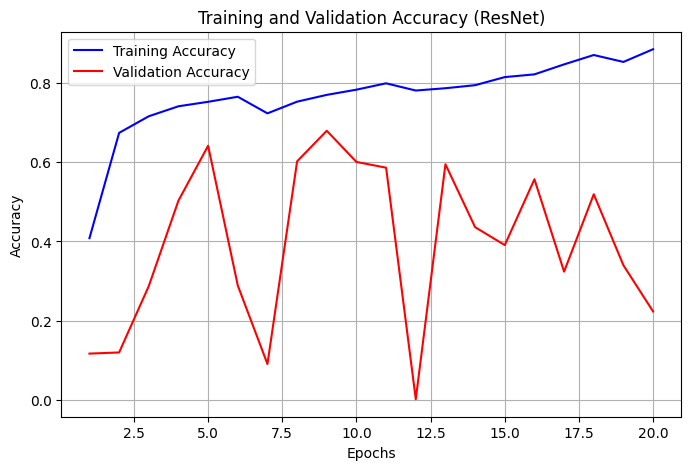

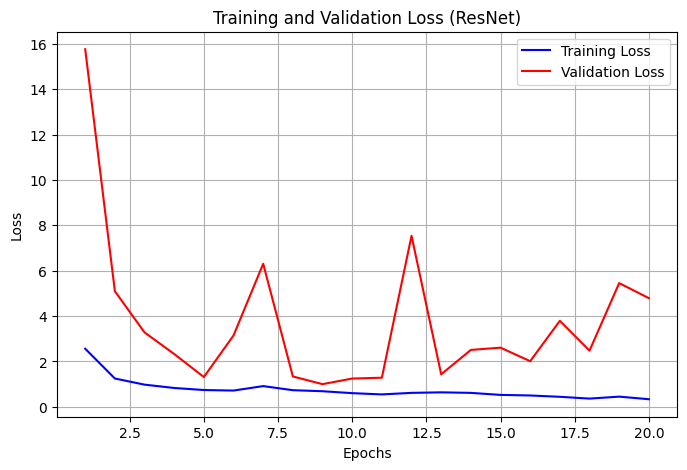

In [12]:
# Plot Accuracy & Loss
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy (ResNet)')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss (ResNet)')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.show()

plot_training(history)

In [13]:
# Save Model
SAVE_DIR = "./model_outputs/resNet"
os.makedirs(SAVE_DIR, exist_ok=True)

In [14]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy (resNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [15]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss (resNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [16]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "resNet_model.h5"))
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [19]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_resNet.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [20]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "global_resNet_training_history.csv"), index=False)

In [21]:
# Convert to DataFrame
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save Classification report
report_path = os.path.join(SAVE_DIR, "resNet_classification_report.csv")
report_df.to_csv(report_path, index=True)

print("[INFO] Save Classification report as CSV")

[INFO] Save Classification report as CSV
